In [1]:
import os
import time
import gc

import numpy as np
import numpy as np
import pandas as pd
from PIL import Image
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
import torch
import albumentations as A
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from albumentations.pytorch import ToTensorV2

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter

from torchmetrics.segmentation import MeanIoU
from torchmetrics import JaccardIndex

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation
from torch.amp import autocast, GradScaler




In [2]:
CONFIG = {
    "epochs": 80,                                   # N° de pasadas del dataset completo
    "batch": 6,  
    "num_clases": 11,                               # Clases del dataset 
    "img_size": 512,                                # Resolución de la imagen de entrada 512x512
    "seed": 42,                                     # Semilla para reproducibilidad
    "data": "../data/",                             # Ruta dataset
    "checkpoint_dir": "../checkpoints/liaci/",      # Ruta chechpoint
    "logs_dir": "../logs/liaci/",
    "mem_dir": "../memoria/benchmark3/"
}

HIPER_UN = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_DL = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_SF = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}


MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Crear carpetas necesarias
#os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
#os.makedirs(CONFIG["logs_dir"], exist_ok=True)
#os.makedirs(CONFIG["mem_dir"], exist_ok=True)

In [3]:
#### GPU Info ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
"""
seg_path = "../data/LIACi/segmentation"   # 
archivos = sorted([f for f in os.listdir(seg_path) if f.endswith(".png")])
print(f"Total máscaras de segmentación: {len(archivos)}")

# Recopilar todos los colores únicos del dataset completo
colores_globales = set()
conteo_pixeles = defaultdict(int)

# Muestreamos (si son muchas, con 100-200 basta para tener todos los colores)
for nombre in archivos[:200]:
    m = np.array(Image.open(os.path.join(seg_path, nombre)).convert("RGB"))
    colores = m.reshape(-1, 3)
    unicos, counts = np.unique(colores, axis=0, return_counts=True)
    for color, count in zip(unicos, counts):
        t = tuple(color)
        colores_globales.add(t)
        conteo_pixeles[t] += count

print(f"\nColores únicos encontrados ({len(colores_globales)}):")
# Ordenar por frecuencia (más píxeles primero)
for color in sorted(colores_globales, key=lambda c: -conteo_pixeles[c]):
    print(f"  RGB{color}: {conteo_pixeles[color]:,} píxeles")
"""

In [4]:
# Ruta csv con split de imágenes
df = pd.read_csv("../data/LIACi/train_test_split.csv")


print("Columnas:", df.columns.tolist())
print(f"\nTotal filas: {len(df)}")
#print("\nPrimeras filas:")
#print(df.head(10))

print("\nDistribución de splits:")
print(df["split"].value_counts())


Columnas: ['Unnamed: 0', 'file_name', 'split']

Total filas: 1893

Distribución de splits:
split
train       1370
not_used     332
test         191
Name: count, dtype: int64


In [5]:
CLASS_NAMES = [
    'Void',                 #void
    'Ship hull',            #Casco de barco
    'Marine growth',        #Crecimiento marino
    'Anode',                #Ánodo
    'Overboard valve',      #Válvula de sesagüe
    'Propeller',            #Hélice
    'Paint peel',           #Desprendimiento de pintura
    'Bilge keel',           #Quilla de balance
    'Defect',               #Defecto
    'Corrosion',            #Corrosión
    'Sea chest grating'     #Rejilla de la toma de mar
]

CLASS_COLORS = [
    (0, 0, 0),              # Void - Negro
    (0, 0, 255),            # Ship hull - Azul
    (0, 128, 0),            # Marine growth - Verde
    (0, 255, 255),          # Anode - Cyan
    (64, 224, 208),         # Overboard valve - Turquesa
    (128, 0, 128),          # Propeller - Purpura
    (255, 0, 0),            # Paint peel - Rojo
    (255, 165, 0),          # Bilge keel - Naranja
    (255, 192, 203),        # Defect - Rosa
    (255, 255, 0),          # Corrosion - Amarillo
    (255, 255, 255),        # Sea chest grating - Blanco
]

cmap_liaci = ListedColormap(np.array(CLASS_COLORS)/255.0)


def convert_color_to_id(mask_rgb):
    """
    Convierte una máscara RGB [H, W, 3] a una máscara de índices [H, W].
    Cada color corresponde a una clase según CLASS_COLORS.
    Los colores no reconocidos se asignan a 0 (Void).
    """
    h, w = mask_rgb.shape[:2]
    # Codificar cada píxel RGB como un único entero: R*256² + G*256 + B
    mask_flat = (mask_rgb[:, :, 0].astype(np.int32) * 256 * 256 +
                 mask_rgb[:, :, 1].astype(np.int32) * 256 +
                 mask_rgb[:, :, 2].astype(np.int32))
    
    # Inicializar todo a 0 (Void)
    mask_id = np.zeros((h, w), dtype=np.uint8)
    
    for idx, (r, g, b) in enumerate(CLASS_COLORS):
        color_code = r * 256 * 256 + g * 256 + b
        mask_id[mask_flat == color_code] = idx
    
    return mask_id

In [6]:
CROP_SIZE = 512  #

transform_train = A.Compose([
    #Multi-scale para variar escala
    A.RandomScale(scale_limit=(-0.5, 0.5), p=1.0,
                  interpolation=cv2.INTER_LINEAR),

    #Padding si algún lado quedó pequeño
    A.PadIfNeeded(
        min_height=CROP_SIZE,
        min_width=CROP_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0     #
    ),
    #Recorte cuadrado
    A.RandomCrop(CROP_SIZE, CROP_SIZE),

    #Flips en ambos ejes (el ROV puede ver desde cualquier ángulo)
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    
    #Rotaciones
    A.RandomRotate90(p=0.5),           # rotaciones múltiplo de 90°
    A.Rotate(limit=30, p=0.5,           # rotaciones pequeñas adicionales
             border_mode=cv2.BORDER_CONSTANT,
             fill=0, fill_mask=0),

    #Color: agresivo por la variabilidad de iluminación subacuática
    A.ColorJitter(brightness=0.4, contrast=0.4, 
                  saturation=0.3, hue=0.05, p=0.7),
    
    #Ruido y blur (turbidez del agua, partículas suspendidas)
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MotionBlur(blur_limit=7, p=1.0),
    ], p=0.3),
    
    A.GaussNoise(std_range=(0.05, 0.15), p=0.3),

    #Normalización estándar ImageNet
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

In [7]:
transform_val = A.Compose([
    # Redimensionado que mantiene aspect ratio + padding para que sea cuadrado
    A.LongestMaxSize(max_size=CROP_SIZE, interpolation=cv2.INTER_LINEAR),
    A.PadIfNeeded(
        min_height=CROP_SIZE,
        min_width=CROP_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0
    ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

In [8]:
def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std = torch.tensor(STD).view(3,1,1)
    return (tensor * std + mean).clamp(0,1)

In [9]:
df = pd.read_csv("../data/LIACi/train_test_split.csv")

In [10]:
class Dataset_LIACi(Dataset):
    def __init__(self, root, split_df, conjunto="train", transform=None):
        """
        root: carpeta raíz de LIACi
        split_df: DataFrame del CSV (con columnas 'file_name' y 'split')
        conjunto: "train" o "test"
        """
        
        self.images_dir = os.path.join(root, "images")
        self.seg_dir = os.path.join(root, "segmentation")
        self.transform = transform

        # Filtrar por split, excluye automáticamente cualquier otro valor
        self.archivos = split_df[split_df["split"] == conjunto]["file_name"].tolist()
        
        print(f"Dataset LIACi [{conjunto}]: {len(self.archivos)} imágenes")

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, indice):
        nombre_img = self.archivos[indice]
        
        # Cargar imagen .jpg
        image = np.array(
            Image.open(os.path.join(self.images_dir, nombre_img)).convert("RGB")
        )
        
        # Máscara: mismo nombre base con extensión .png
        nombre_mask = nombre_img.replace(".jpg", ".png")
        mask_rgb = np.array(
            Image.open(os.path.join(self.seg_dir, nombre_mask)).convert("RGB")
        )
        mask = convert_color_to_id(mask_rgb)
        
        # Aplicar transformaciones
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        
        if not torch.is_tensor(mask):
            mask = torch.from_numpy(mask)
        return image, mask.long()

In [11]:
#Crear datasets
train_dataset = Dataset_LIACi(
    root="../data/LIACi",
    split_df=df,
    conjunto="train",
    transform=transform_train
)


Dataset LIACi [train]: 1370 imágenes


In [12]:
test_dataset = Dataset_LIACi(
    root="../data/LIACi",
    split_df=df,
    conjunto="test",
    transform=transform_val
)

Dataset LIACi [test]: 191 imágenes


# DataLoader

In [13]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=CONFIG["batch"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=CONFIG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Train: 1370
Test:  191
Total: 1561 (CSV tiene 1893)

Imagen: shape=torch.Size([3, 512, 512]), dtype=torch.float32
Máscara: shape=torch.Size([512, 512]), dtype=torch.int64
Clases presentes: [0, 1, 6, 7]
Nombres: ['Void', 'Ship hull', 'Paint peel', 'Bilge keel']


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

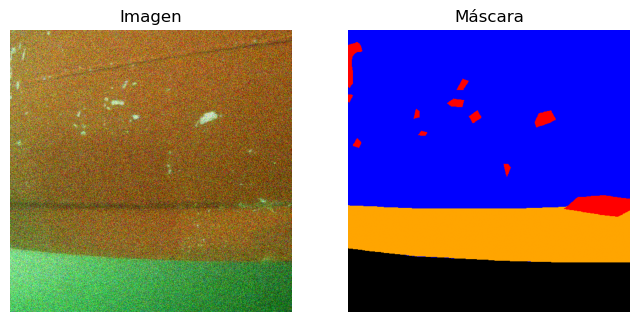

In [14]:
# Verificar tamaños
print(f"Train: {len(train_dataset)}")
print(f"Test:  {len(test_dataset)}")
print(f"Total: {len(train_dataset) + len(test_dataset)} (CSV tiene {len(df)})")

# Cargar un ejemplo
image, mask = train_dataset[0]
print(f"\nImagen: shape={image.shape}, dtype={image.dtype}")
print(f"Máscara: shape={mask.shape}, dtype={mask.dtype}")
print(f"Clases presentes: {torch.unique(mask).tolist()}")
print(f"Nombres: {[CLASS_NAMES[c] for c in torch.unique(mask).tolist()]}")


fig, axes = plt.subplots(1, 2, figsize=(8, 8))
img = desnormalizar(image).permute(1,2,0).numpy()
#m = desnormalizar(mask).permute(1,2,0).numpy()

axes[0].imshow(img)
axes[0].set_title("Imagen")
axes[0].axis("off")

axes[1].imshow(mask, cmap=cmap_liaci, vmin=0, vmax=10)
axes[1].set_title("Máscara")
axes[1].axis("off")


# Visualizar dataloader

In [15]:
def visualizar_ejemplos(images, masks, n=6):
    
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for i in range(n):
        img = desnormalizar(images[i]).permute(1,2,0).numpy()
        axes[0,i].imshow(img)
        axes[0,i].set_title("Imagen")
        axes[0,i].axis("off")

        axes[1,i].imshow((masks[i].numpy()), cmap=cmap_liaci, vmin=0, vmax=10)
        axes[1,i].set_title("Máscara")
        axes[1,i].axis("off")

    plt.suptitle("Ejemplos dataset LIACI", fontsize=14)
    plt.tight_layout()
    plt.show()

Shape imágenes:  torch.Size([6, 3, 512, 512])
Shape máscaras:  torch.Size([6, 512, 512])
Clases únicas:   tensor([0, 1, 2, 3, 4, 5, 6])


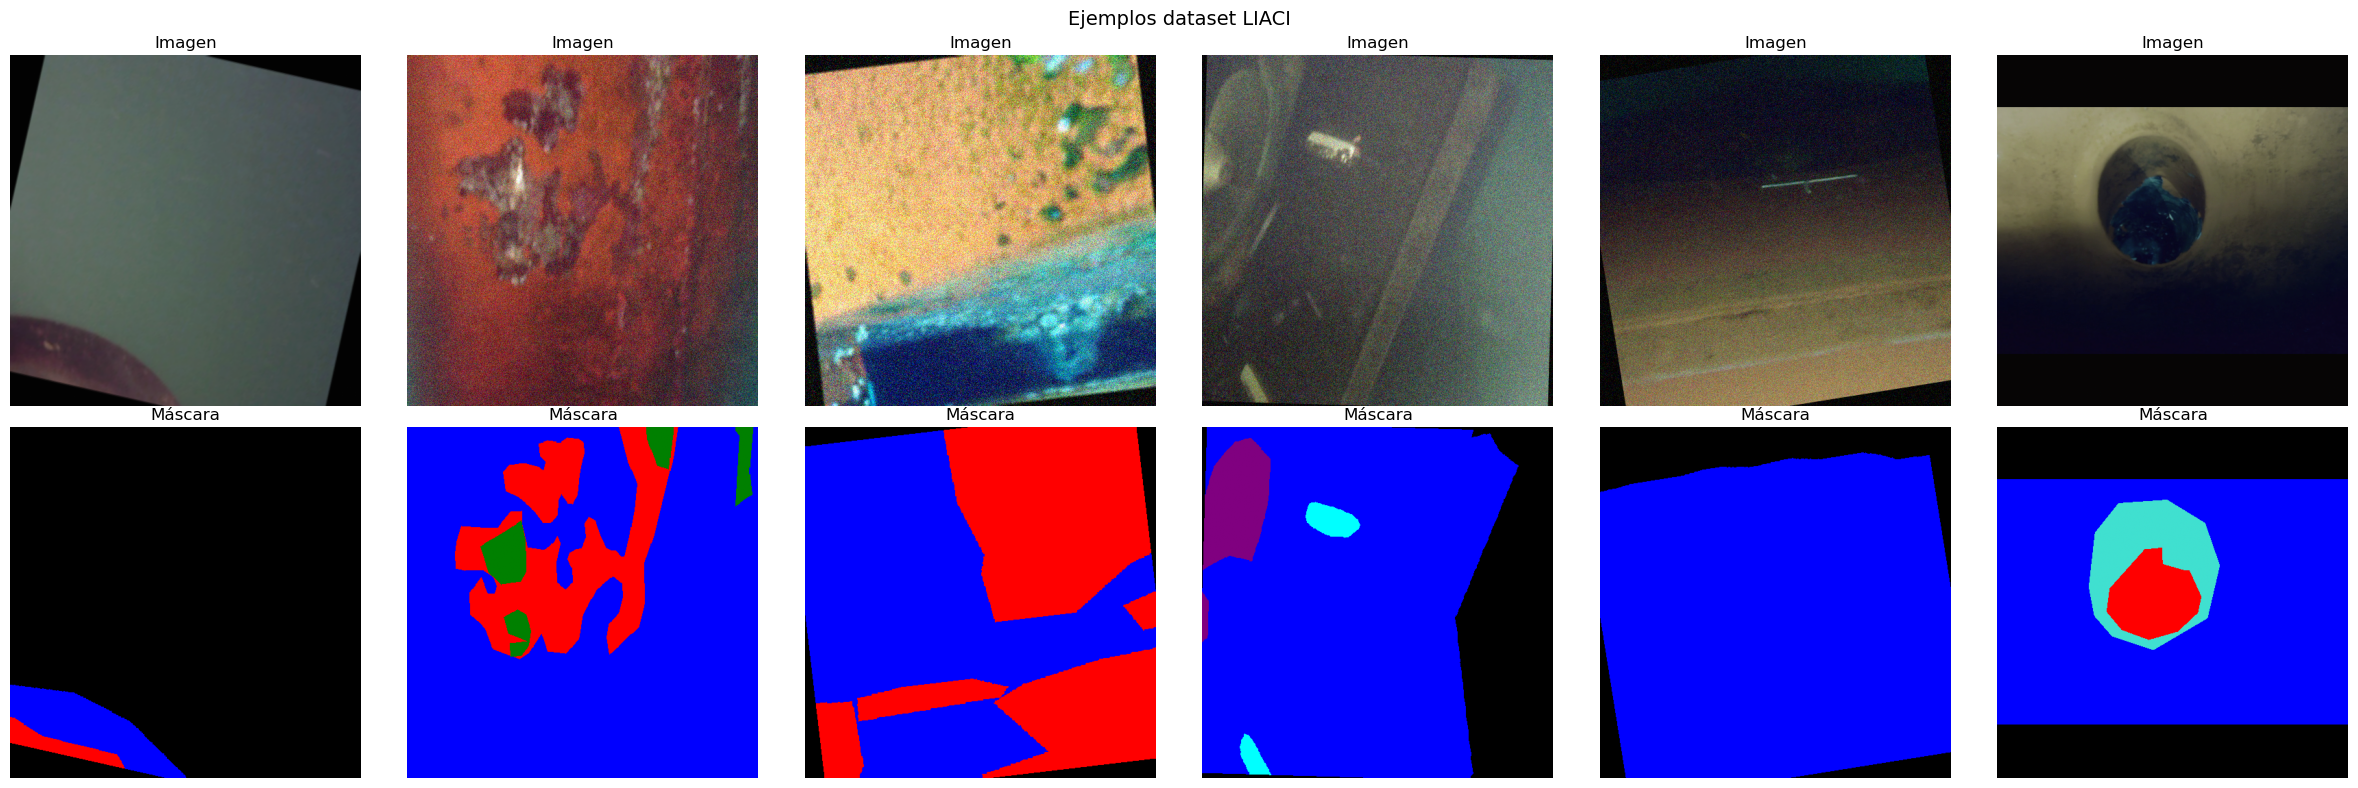

In [16]:
# Verificar shapes
images, masks = next(iter(train_loader))
print(f"Shape imágenes:  {images.shape}")
print(f"Shape máscaras:  {masks.shape}")
print(f"Clases únicas:   {masks.unique()}")

# Visualizar
visualizar_ejemplos(images, masks)

## Definir modelos

In [17]:
# U-Net 
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_unet(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:], 
                           mode="bilinear", align_corners=False)
    return out
    
print(f"** U-Net -> N° parámetros: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")
print("\n** Modelo U-Net cargado")

** U-Net -> N° parámetros: 32.5M

** Modelo U-Net cargado


In [18]:
# DeepLabV3
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_deeplabv3plus(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:],
                           mode="bilinear", align_corners=False)
    return out

print(f"\n** DeepLabV3Plus -> N° parámetros: {sum(p.numel() for p in deeplabv3plus.parameters())/1e6:.1f}M")
print("\n** Modelo DeepLabV3Plus cargado")


** DeepLabV3Plus -> N° parámetros: 26.7M

** Modelo DeepLabV3Plus cargado


In [19]:
# SegFormer
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

def forward_segformer(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=images.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

print(f"\n\n\n** SegFormer -> N° parámetros: {sum(p.numel() for p in segformer.parameters())/1e6:.1f}M")
print("\n** Modelo SegFormer cargado")

[transformers] You passed `num_labels=11` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr




** SegFormer -> N° parámetros: 27.4M

** Modelo SegFormer cargado


## Definición de la función de pérdida

In [20]:
class perdidaDiceCE(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            
        )
        self.ce = nn.CrossEntropyLoss()

    def forward(self, pred, obj):
        return 0.5 * self.dice(pred, obj) + 0.5 * self.ce(pred, obj)

loss_fn = perdidaDiceCE()
print("-> Función de pérdida definida")

-> Función de pérdida definida


## Bucle de entrenamiento

In [21]:
def entrenar_modelo(modelo, nombre, forward_fn, hiper):

    ############################
    # Reset de semilla
    torch.manual_seed(CONFIG["seed"])
    np.random.seed(CONFIG["seed"])
    ############################

    modelo = modelo.to(device)

    writer  = SummaryWriter(log_dir=f"../logs/liaci/{nombre}")

    miou_fn = JaccardIndex(
        task="multiclass",
        num_classes=CONFIG["num_clases"],
        average="macro"
    ).to(device)
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=hiper["lr"],
        weight_decay=hiper["weight_decay"]
    )
    """ 
    # Actualización de la tasa de aprendizaje.##############
    """
    scheduler_step_per_iter=False
    if (nombre == "unet"):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["epochs"], eta_min=1e-6
        )
        scheduler_step_per_iter = False

    elif(nombre == "deeplabv3plus"):
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=0.9
        )
        scheduler_step_per_iter = True

    else:
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=1.0
        )
        scheduler_step_per_iter = True
    
    """ 
    ########################################################
    """

    scaler = GradScaler("cuda")
    
    historial = {
        "loss_train": [],
        "miou_val": []
    }

    tiempo_entrenamiento = 0.0
    mejor_miou = 0.0
    
    for epoch in range(CONFIG["epochs"]):

        # Aquí empieza el entrenamiento de cada epoch
        inicio_epoch = time.time()
        # -- Train ---------------------------
        modelo.train()
        loss_total = 0

        pbar = tqdm(
            train_loader,
            desc=f"[{nombre}] Epoch {epoch+1}/{CONFIG['epochs']}",
            leave=False
        )

        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.long().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast("cuda"):
                preds = forward_fn(modelo, images)
                loss = loss_fn(preds, masks)


            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if scheduler_step_per_iter:
                scheduler.step()

            loss_total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")


        loss_media = loss_total / len(train_loader)

        

        # -- Validación ---------------------------
        modelo.eval()
        miou_fn.reset()

        with torch.no_grad():
            for images, masks in test_loader:
                images = images.to(device)
                masks  = masks.long().to(device)
                preds  = forward_fn(modelo, images).argmax(dim=1)
                miou_fn.update(preds, masks)


        miou_val = miou_fn.compute().item()   
            

        tiempo_epoch = (time.time() - inicio_epoch)/60 # tiempo en min del entrenamiento de cada epochs.
        # -- Sumar tiempo epoch ---------------------------
        tiempo_entrenamiento += tiempo_epoch    # Sumo tiempo de epoch.

        # -- Guardar historial ---------------------------
        historial["loss_train"].append(loss_media)
        historial["miou_val"].append(miou_val)
        
        # -- TensorBoard ---------------------------
        writer.add_scalar("Loss/train", loss_media, epoch)
        writer.add_scalar("mIoU/val", miou_val, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
        writer.add_scalar("Tiempo/epoch", tiempo_epoch, epoch)

        print(f"[{nombre}] Epoch {epoch+1:02d} | Loss: {loss_media:.4f} | mIoU: {miou_val*100:.2f}% | Tiempo: {tiempo_epoch:.2f} min")

        # -- Guardar mejor modelo ---------------------------
        if miou_val > mejor_miou:
            mejor_miou = miou_val
            torch.save({
                "epoch": epoch,
                "modelo": modelo.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "mejor_miou": mejor_miou,
                "historial": historial
            },
            f"{CONFIG['checkpoint_dir']}{nombre}_b3_checkpoint.pth"
            )
            print(f"  -- Guardado modelo {nombre} con mIoU = {mejor_miou*100:.2f}%")

        if not scheduler_step_per_iter:
            scheduler.step()   # disminuye learning rate.
    
    writer.close()
    
    print(f"\n\n-->>    {nombre} completado | Mejor mIoU: {mejor_miou*100:.2f}% | Tiempo total de entrenamiento: {tiempo_entrenamiento:.2f} min   <<--")


    

    
    #--- Libero memoria VRAM ------------------
    modelo.cpu()
    del modelo
    del optimizer
    del scheduler
    del miou_fn
    del scaler  ##
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    #--------------------------------
    
    

    return mejor_miou, historial, tiempo_entrenamiento

In [22]:
# Entrenar U-Net
miou_unet, hist_unet, tiempo_unet = entrenar_modelo(
    unet, "unet", forward_unet, HIPER_UN
)

[unet] Epoch 1/80:   0%|          | 0/229 [00:00<?, ?it/s]

[unet] Epoch 01 | Loss: 1.1372 | mIoU: 19.45% | Tiempo: 1.56 min
  -- Guardado modelo unet con mIoU = 19.45%


[unet] Epoch 2/80:   0%|          | 0/229 [00:00<?, ?it/s]

[unet] Epoch 02 | Loss: 0.8979 | mIoU: 21.24% | Tiempo: 1.51 min
  -- Guardado modelo unet con mIoU = 21.24%


[unet] Epoch 3/80:   0%|          | 0/229 [00:00<?, ?it/s]

...

[unet] Epoch 78 | Loss: 0.4766 | mIoU: 44.24% | Tiempo: 1.50 min
  -- Guardado modelo unet con mIoU = 44.24%


[unet] Epoch 79/80:   0%|          | 0/229 [00:00<?, ?it/s]

[unet] Epoch 79 | Loss: 0.4881 | mIoU: 42.98% | Tiempo: 1.50 min


[unet] Epoch 80/80:   0%|          | 0/229 [00:00<?, ?it/s]

[unet] Epoch 80 | Loss: 0.4707 | mIoU: 43.07% | Tiempo: 1.48 min


-->>    unet completado | Mejor mIoU: 44.24% | Tiempo total de entrenamiento: 120.09 min   <<--


In [23]:
#Entrenar DeepLabV3Plus
miou_deeplabv3plus, hist_deeplabv3plus, tiempo_deeplabv3plus = entrenar_modelo(
    deeplabv3plus, "deeplabv3plus", forward_deeplabv3plus, HIPER_DL
)

[deeplabv3plus] Epoch 1/80:   0%|          | 0/229 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 01 | Loss: 0.9895 | mIoU: 21.04% | Tiempo: 1.39 min
  -- Guardado modelo deeplabv3plus con mIoU = 21.04%


[deeplabv3plus] Epoch 2/80:   0%|          | 0/229 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 02 | Loss: 0.8083 | mIoU: 24.50% | Tiempo: 1.34 min
  -- Guardado modelo deeplabv3plus con mIoU = 24.50%


[deeplabv3plus] Epoch 3/80:   0%|          | 0/229 [00:00<?, ?it/s]

...

[deeplabv3plus] Epoch 78 | Loss: 0.3633 | mIoU: 49.96% | Tiempo: 1.34 min


[deeplabv3plus] Epoch 79/80:   0%|          | 0/229 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 79 | Loss: 0.3603 | mIoU: 50.12% | Tiempo: 1.34 min


[deeplabv3plus] Epoch 80/80:   0%|          | 0/229 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 80 | Loss: 0.3496 | mIoU: 49.89% | Tiempo: 1.35 min


-->>    deeplabv3plus completado | Mejor mIoU: 50.95% | Tiempo total de entrenamiento: 106.64 min   <<--


In [24]:
# Entrenar SegFormer
miou_segformer, hist_segformer, tiempo_segformer = entrenar_modelo(
    segformer, "segformer", forward_segformer, HIPER_SF
)

[segformer] Epoch 1/80:   0%|          | 0/229 [00:00<?, ?it/s]

[segformer] Epoch 01 | Loss: 0.8552 | mIoU: 30.10% | Tiempo: 2.02 min
  -- Guardado modelo segformer con mIoU = 30.10%


[segformer] Epoch 2/80:   0%|          | 0/229 [00:00<?, ?it/s]

[segformer] Epoch 02 | Loss: 0.6943 | mIoU: 38.48% | Tiempo: 1.98 min
  -- Guardado modelo segformer con mIoU = 38.48%


[segformer] Epoch 3/80:   0%|          | 0/229 [00:00<?, ?it/s]

...

[segformer] Epoch 78 | Loss: 0.1935 | mIoU: 62.76% | Tiempo: 1.98 min
  -- Guardado modelo segformer con mIoU = 62.76%


[segformer] Epoch 79/80:   0%|          | 0/229 [00:00<?, ?it/s]

[segformer] Epoch 79 | Loss: 0.1885 | mIoU: 62.36% | Tiempo: 1.99 min


[segformer] Epoch 80/80:   0%|          | 0/229 [00:00<?, ?it/s]

[segformer] Epoch 80 | Loss: 0.1983 | mIoU: 62.55% | Tiempo: 1.97 min


-->>    segformer completado | Mejor mIoU: 62.76% | Tiempo total de entrenamiento: 158.25 min   <<--


### Almacenar historial entrenamiento en csv

In [25]:
# Guardar miou por epoch de los tres modelos
res_e_miou=[]

for epoch in range(len(hist_unet["miou_val"])):
    res_e_miou.append({
        "Epoch":epoch+1,
        "U-Net":hist_unet["miou_val"][epoch],
        "DeepLabv3plus":hist_deeplabv3plus["miou_val"][epoch],
        "SegFormer":hist_segformer["miou_val"][epoch]
    })


In [26]:
dfmiou = pd.DataFrame(res_e_miou)
display(dfmiou)

,Epoch,U-Net,DeepLabv3plus,SegFormer
0,1,0.194520,0.210421,0.300986
1,2,0.212410,0.245005,0.384788
2,3,0.232768,0.298073,0.367281
3,4,0.226481,0.313164,0.404722
4,5,0.233092,0.345560,0.397917
...,...,...,...,...
75,76,0.430219,0.497392,0.625308
76,77,0.427308,0.496636,0.626281
77,78,0.442432,0.499569,0.627645
78,79,0.429816,0.501239,0.623603


In [34]:
dfmiou.to_csv(CONFIG["mem_dir"]+"epochs_miou_b3_entrenamiento.csv")

## Visualizar y almacenar datos de entrenamiento

In [27]:
"""
ALMACENAR MEJOR mIoU ENTRENAMIENTO.
"""
res_mejor=[]
mejor_unet={"Modelo":"U-Net", 
            "Mejor mIoU(%) entrenamiento":round(miou_unet*100,2), 
            "Tiempo entrenamiento (min)":round(tiempo_unet,2)}
res_mejor.append(mejor_unet)

mejor_deeplabv3plus={"Modelo":"DeepLabV3plus",
                     "Mejor mIoU(%) entrenamiento":round(miou_deeplabv3plus*100,2),
                     "Tiempo entrenamiento (min)":round(tiempo_deeplabv3plus,2)}
res_mejor.append(mejor_deeplabv3plus)

mejor_segformer={"Modelo":"SegFormer",
                 "Mejor mIoU(%) entrenamiento":round(miou_segformer*100,2),
                 "Tiempo entrenamiento (min)":round(tiempo_segformer,2)}
res_mejor.append(mejor_segformer)


t = pd.DataFrame(res_mejor)
display(t)

,Modelo,Mejor mIoU(%) entrenamiento,Tiempo entrenamiento (min)
0,U-Net,44.24,120.09
1,DeepLabV3plus,50.95,106.64
2,SegFormer,62.76,158.25


In [28]:
t.to_csv(CONFIG["mem_dir"]+"resultados_b3_entrenamiento.csv")

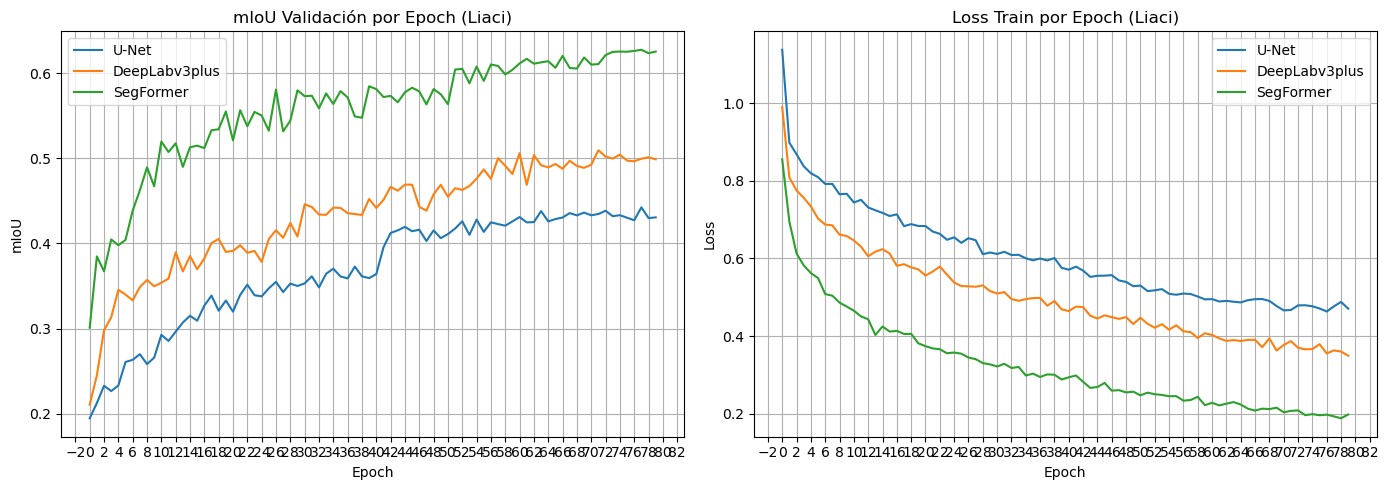

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas mIoU
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[0].plot(hist["miou_val"], label=nombre)

axes[0].set_title("mIoU Validación por Epoch (Liaci)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mIoU")
axes[0].legend()
axes[0].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[0].grid(True)

# Curvas Loss
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[1].plot(hist["loss_train"], label=nombre)

axes[1].set_title("Loss Train por Epoch (Liaci)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[1].grid(True)

plt.tight_layout()
plt.savefig(CONFIG["mem_dir"]+"curvas_entrenamiento_b3.png", dpi=150)
plt.show()